# Fit $ee \to c \bar{c}$ data using K matrix formalism

In [1]:
%matplotlib inline

import eos
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 7]

## Test Parameters and Observables

In [2]:
params = eos.Parameters.Defaults()
params.set("ee->ccbar::g0(psi(2S),ee)",           0.0029)
params.set("ee->ccbar::g0(psi(3770),ee)",         0.00037)
params.set("ee->ccbar::g0(psi(2S),D^0Dbar^0)",   -0.0398)
params.set("ee->ccbar::g0(psi(3770),D^0Dbar^0)",  0.6368)
params.set("ee->ccbar::g0(psi(2S),D^+D^-)",       0.0108)
params.set("ee->ccbar::g0(psi(3770),D^+D^-)",    -0.5297)
params.set("ee->ccbar::Rconstant",                2.2)

display(eos.Constraints(prefix='ee->ccbar'))

Name,Type
ee->ccbar::R_c@BESII2002,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoD0Dbar0@BaBar2007,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoD0Dbar0@Belle2008,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoD0Dbarst0@CLEO2009,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoDpDm@BaBar2007,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoDpDm@Belle2008,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoDpDstm@CLEO2009,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoDspDsm@CLEO2009,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoDspDsstm@CLEO2009,MultivariateGaussian (using covariance matrix)
ee->ccbar::sigma_eetoDsstpDsstm@CLEO2009,MultivariateGaussian (using covariance matrix)


In [3]:
eetoee4 = eos.Observable.make("ee->ccbar::sigma_eetoee(E)", params, eos.Kinematics(E = 4), eos.Options())
eetoeff4 = eos.Observable.make("ee->ccbar::sigma_eetoeff(E)", params, eos.Kinematics(E = 4), eos.Options())
eetoD0Dbar04 = eos.Observable.make("ee->ccbar::sigma_eetoD0Dbar0(E)", params, eos.Kinematics(E = 4), eos.Options())
eetoDpDm4 = eos.Observable.make("ee->ccbar::sigma_eetoDpDm(E)", params, eos.Kinematics(E = 4), eos.Options())
eetoD0Dbarst04 = eos.Observable.make("ee->ccbar::sigma_eetoD0Dbarst0(E)", params, eos.Kinematics(E = 4), eos.Options())
eetoDpDstm4 = eos.Observable.make("ee->ccbar::sigma_eetoDpDstm(E)", params, eos.Kinematics(E = 4), eos.Options())
eetoDspDsm4 = eos.Observable.make("ee->ccbar::sigma_eetoDspDsm(E)", params, eos.Kinematics(E = 4), eos.Options())
eetoRc4 = eos.Observable.make("ee->ccbar::R_c(E)", params, eos.Kinematics(E = 4), eos.Options())

psi2S_ee_width = eos.Observable.make("ee->ccbar::psi2S_ee_width", params, eos.Kinematics(), eos.Options())

#display(eetoee4, eetoeff4, eetoD0Dbar04, eetoDpDm4, eetoD0Dbarst04, eetoDpDstm4, eetoDspDsm4, eetoRc4, psi2S_ee_width)

## Fit up to DD* threshold (3.87164 GeV) in the isospin limit

In [4]:
analysis_toDDst_args = {
    'global_options': {},
    'manual_constraints': {
        'psi2S::decay_width': {
            'type': 'Gaussian',
            'observable': 'ee->ccbar::psi2S_ee_width',
            'kinematics' : {},
            'options' : {},
            'mean': 2.331e-6,
            'sigma-stat': { 'hi': 0.064e-6, 'lo': 0.064e-6 },
            'sigma-sys': { 'hi': 0.0, 'lo': 0.0 },
            'dof': 1
        }
    },
    'priors': [
#        { 'parameter': "mass::psi(2S)",                      'min':  3.6, 'max':  3.7, 'type': 'uniform' },
#        { 'parameter': "mass::psi(3770)",                    'min': 3.72, 'max': 3.85, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(2S),ee)",          'min':  0.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),ee)",        'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(2S),eff)",         'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),eff)",       'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(2S),D^0Dbar^0)",   'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),D^0Dbar^0)", 'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(2S),D^+D^-)",      'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(3770),D^+D^-)",    'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::Rconstant",               'min':  1.8, 'max':  2.4, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::c(ee,eff)",               'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,D^0Dbar^0)",         'min': -1.0, 'max':  1.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::c(ee,D^+D^-)",            'min': -1.0, 'max':  1.0, 'type': 'uniform' }
    ],
    'likelihood': [
        'ee->ccbar::sigma_eetoD0Dbar0@Belle2008;begin=0,end=9',
        'ee->ccbar::sigma_eetoDpDm@Belle2008;begin=0,end=9',
        'ee->ccbar::sigma_eetoD0Dbar0@BaBar2007;begin=0,end=8',
        'ee->ccbar::sigma_eetoDpDm@BaBar2007;begin=0,end=7',
        'ee->ccbar::R_c@BESII2002;begin=0,end=22',
    ]
}
analysis_toDDst = eos.Analysis(**analysis_toDDst_args)

In [5]:
%%time
bfp_toDDst = analysis_toDDst.optimize(
    start_point = [0.0029, 0.0005, 0.0108, 0.0981, 1.4228, 4.8034, 2.2349, 0.0098]
    )
display(bfp_toDDst)
display(analysis_toDDst.goodness_of_fit())

parameter,value
"$g^0(\psi(2S),e^+e^-)$",0.0029
"$g^0(\psi(3770),e^+e^-)$",0.0005
"$g^0(\psi(2S),\textrm{eff})$",0.0108
"$g^0(\psi(3770),\textrm{eff})$",0.0981
"$g^0(\psi(2S),D^0\bar{D}^0)$",1.4230
"$g^0(\psi(3770),D^0\bar{D}^0)$",4.8040
$R_{uds}$,2.2346
"$\hat{c}(e^+e^-, D^0\bar{D}^0)$",0.0098


CPU times: user 9min 47s, sys: 1.32 s, total: 9min 49s
Wall time: 1min 18s


## Plot

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


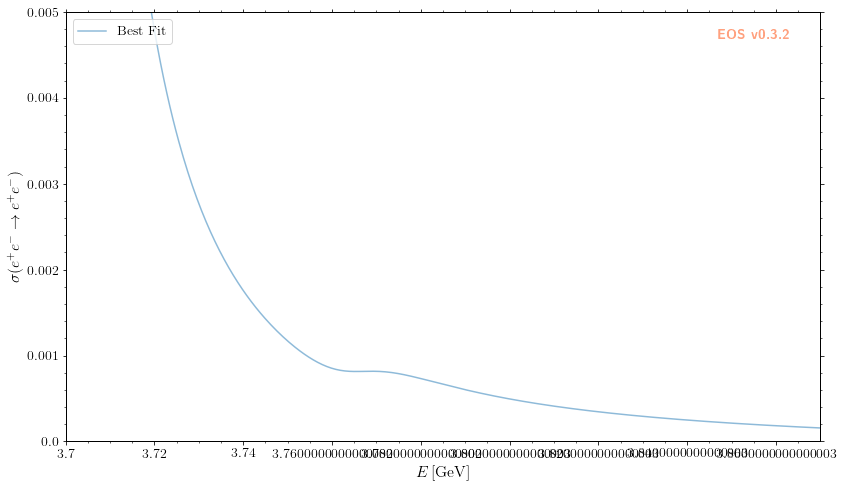

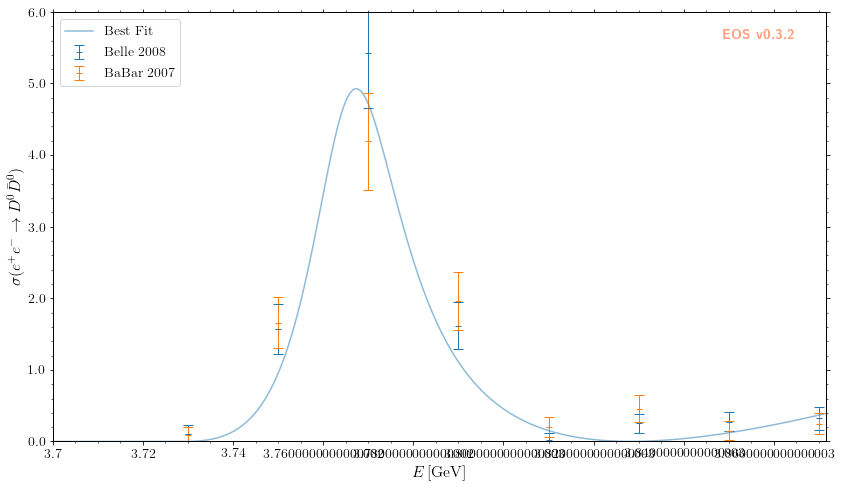

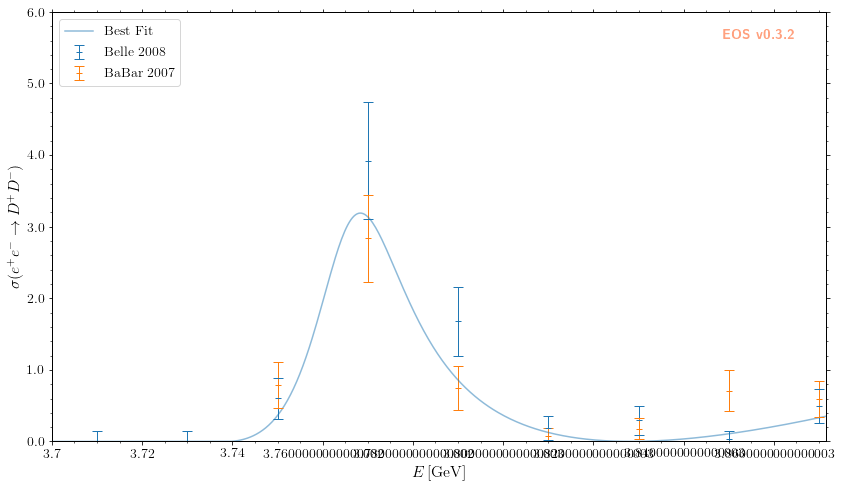

In [6]:
keys = np.array([#"mass::psi(3770)",
                 "ee->ccbar::g0(psi(2S),ee)",
                 "ee->ccbar::g0(psi(3770),ee)",
                 "ee->ccbar::g0(psi(2S),eff)",
                 "ee->ccbar::g0(psi(3770),eff)",
                 "ee->ccbar::g0(psi(2S),D^0Dbar^0)",
                 "ee->ccbar::g0(psi(3770),D^0Dbar^0)",
#                 "ee->ccbar::g0(psi(2S),D^+D^-)",
#                 "ee->ccbar::g0(psi(3770),D^+D^-)",
                 "ee->ccbar::Rconstant",
#                 "ee->ccbar::c(ee,eff)",
                 "ee->ccbar::c(ee,D^0Dbar^0)",
#                 "ee->ccbar::c(ee,D^+D^-)"
                ])
bfp_dict = dict(zip(keys, bfp_toDDst.point))

plotee_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 3.87] },
        'y': { 'label': r'$\sigma(e^+e^-\to e^+e^-)$',          'range': [0., 0.005] },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoee(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 3.87],
            'samples': 500
        },
    ]
}
eos.plot.Plotter(plotee_args).plot()

plotD0Dbar0_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 3.87164] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^0 \bar{D}^0)$',   'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoD0Dbar0(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 3.87164],
            'samples': 500
        },
        {
            'label': r'Belle 2008',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbar0@Belle2008',
            'observable': 'ee->ccbar::sigma_eetoD0Dbar0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
        {
            'label': r'BaBar 2007',
            'type': 'constraint',
            'color': 'C1',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbar0@BaBar2007',
            'observable': 'ee->ccbar::sigma_eetoD0Dbar0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotD0Dbar0_args).plot()

plotDpDm_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 3.87164] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^+D^-)$',          'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoDpDm(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 3.87164],
            'samples': 500
        },
        {
            'label': r'Belle 2008',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoDpDm@Belle2008',
            'observable': 'ee->ccbar::sigma_eetoDpDm(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
        {
            'label': r'BaBar 2007',
            'type': 'constraint',
            'color': 'C1',
            'constraints': 'ee->ccbar::sigma_eetoDpDm@BaBar2007',
            'observable': 'ee->ccbar::sigma_eetoDpDm(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotDpDm_args).plot()

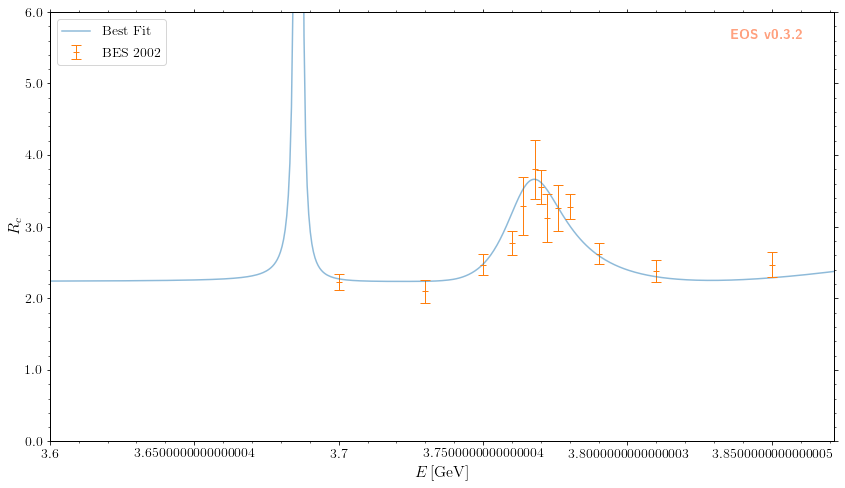

In [7]:
plotRc_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.6, 3.87164] },
        'y': { 'label': r'$R_c$',          'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::R_c(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.6, 3.87164],
            'samples': 500
        },
        {
            'label': r'BES 2002',
            'type': 'constraint',
            'constraints': 'ee->ccbar::R_c@BESII2002',
            'observable': 'ee->ccbar::R_c(E)',
            'variable': 'E',
            'rescale-by-width': False
        },

    ]
}
eos.plot.Plotter(plotRc_args).plot()

## Fit up to D\*D* threshold (4.0137 GeV) in the isospin limit

In [8]:
analysis_toDstDst_args = {
    'global_options': {},
    'manual_constraints': {
        'psi2S::decay_width': {
            'type': 'Gaussian',
            'observable': 'ee->ccbar::psi2S_ee_width',
            'kinematics' : {},
            'options' : {},
            'mean': 2.331e-6,
            'sigma-stat': { 'hi': 0.064e-6, 'lo': 0.064e-6 },
            'sigma-sys': { 'hi': 0.0, 'lo': 0.0 },
            'dof': 1
        }
    },
    'priors': [
        { 'parameter': "ee->ccbar::g0(psi(2S),ee)",           'min': 0.002, 'max': 0.004, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),ee)",         'min': -0.01, 'max': 0.01, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),ee)",         'min': -0.01, 'max': 0.01, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(2S),eff)",          'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),eff)",        'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),eff)",        'min': -1.0, 'max':  0.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(2S),D^0Dbar^0)",    'min': -2.5, 'max':  0.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),D^0Dbar^0)",  'min':  0.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4040),D^0Dbar^0)",  'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::Rconstant",                'min':  1.5, 'max':  2.2, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(2S),D^0Dbar^*0)",   'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),D^0Dbar^*0)", 'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),D^0Dbar^*0)", 'min': -1.0, 'max':  0.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(2S),D_s^+D_s^-)",   'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),D_s^+D_s^-)", 'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),D_s^+D_s^-)", 'min':  0.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,eff)",                'min': -0.1, 'max':  0.1, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,D^0Dbar^0)",          'min': -0.1, 'max':  0.1, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,D^0Dbar^*0)",         'min': -0.1, 'max':  0.1, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,D_s^+D_s^-)",         'min': -0.1, 'max':  0.1, 'type': 'uniform' }
    ],
    'likelihood': [
        'ee->ccbar::sigma_eetoD0Dbar0@Belle2008;begin=0,end=16',
        'ee->ccbar::sigma_eetoDpDm@Belle2008;begin=0,end=16',
        'ee->ccbar::sigma_eetoD0Dbar0@BaBar2007;begin=0,end=15',
        'ee->ccbar::sigma_eetoDpDm@BaBar2007;begin=0,end=14',
        'ee->ccbar::sigma_eetoD0Dbarst0@CLEO2009;begin=0,end=3',
        'ee->ccbar::sigma_eetoDpDstm@CLEO2009;begin=0,end=3',
        'ee->ccbar::sigma_eetoDspDsm@CLEO2009;begin=0,end=3',
        'ee->ccbar::R_c@BESII2002;begin=0,end=32',
    ]
}
analysis_toDstDst = eos.Analysis(**analysis_toDstDst_args)

In [ ]:
%%time
bfp_toDstDst = analysis_toDstDst.optimize(
    start_point = [ 2.93335456e-03,  3.62219007e-04, -4.20914326e-04,
                    3.62733614e-03,  1.78106767e-01, -2.67146314e-01,
                   -2.19922910e+00,  3.40205128e+00,
                    1.64547192e+00,
                   -1.85527124e-01, -3.25713602e-01,
                    2.47677827e-02,  2.77404710e-01,
                   -9.59076401e-04, -8.96042254e-04,
                    9.11946234e-04,  3.46108546e-03
                  ]
    )
display(bfp_toDstDst.point)
display(analysis_toDstDst.goodness_of_fit())

## Plot

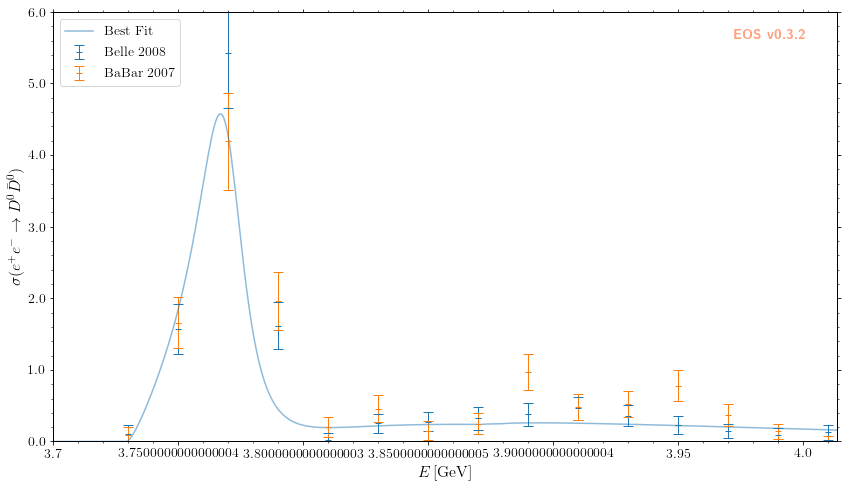

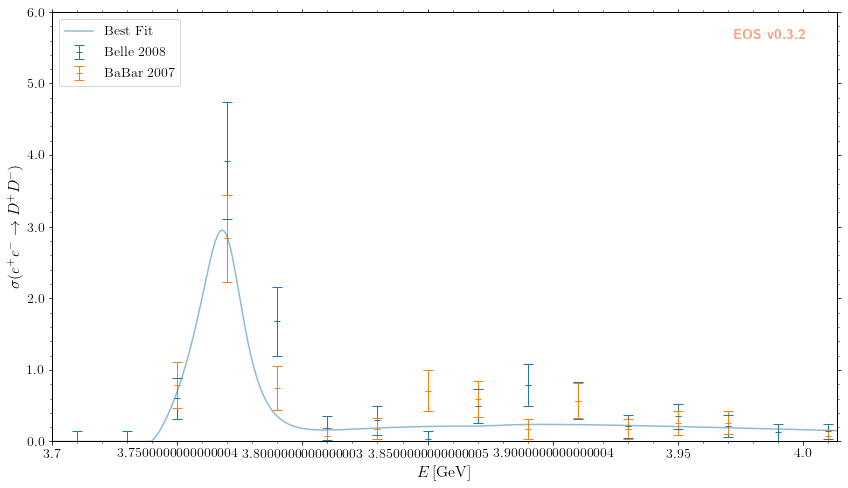

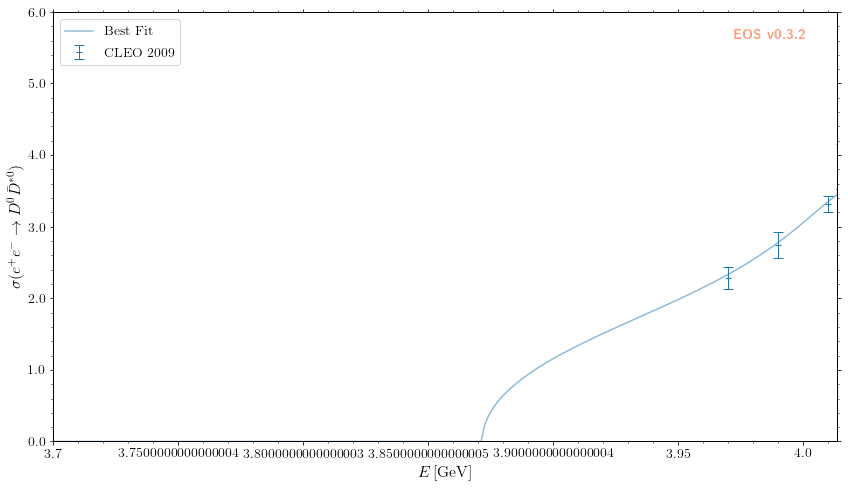

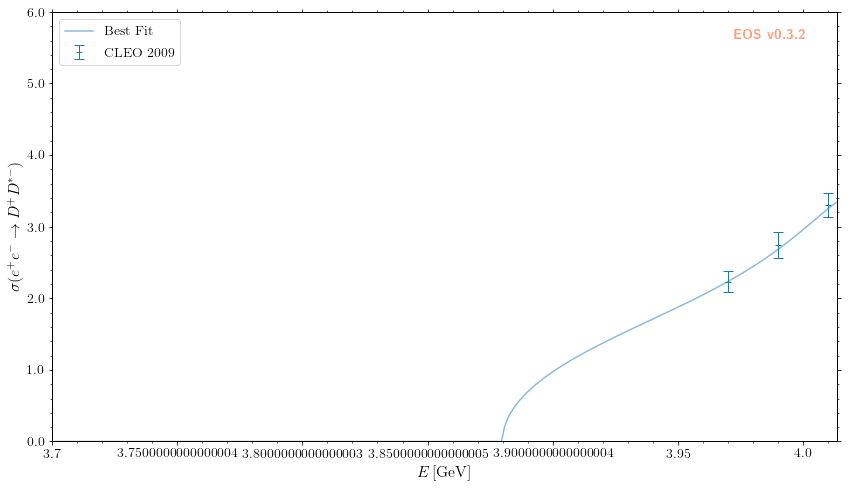

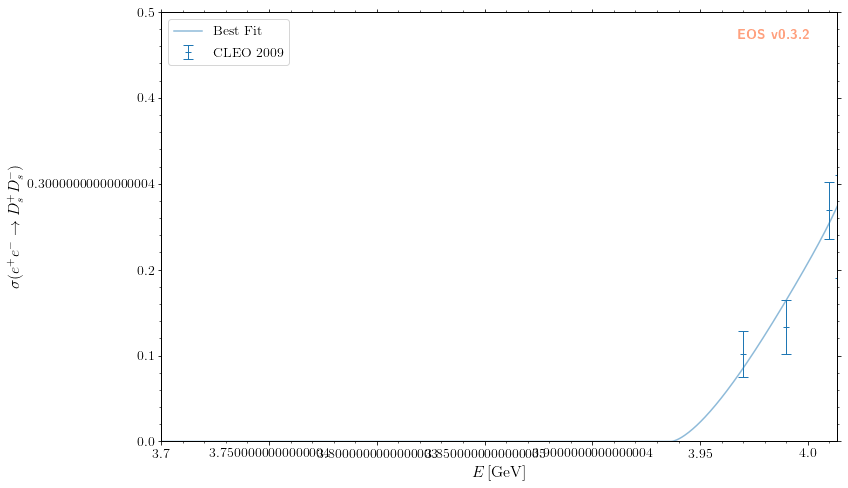

In [11]:
keys = np.array([#"mass::psi(3770)",
                 "ee->ccbar::g0(psi(2S),ee)",
                 "ee->ccbar::g0(psi(3770),ee)",
                 "ee->ccbar::g0(psi(4040),ee)",
                 "ee->ccbar::g0(psi(2S),eff)",
                 "ee->ccbar::g0(psi(3770),eff)",
                 "ee->ccbar::g0(psi(4040),eff)",
                 "ee->ccbar::g0(psi(2S),D^0Dbar^0)",
                 "ee->ccbar::g0(psi(3770),D^0Dbar^0)",
#                 "ee->ccbar::g0(psi(4040),D^0Dbar^0)",
                 "ee->ccbar::Rconstant",
#                 "ee->ccbar::g0(psi(2S),D^0Dbar^*0)",
                 "ee->ccbar::g0(psi(3770),D^0Dbar^*0)",
                 "ee->ccbar::g0(psi(4040),D^0Dbar^*0)",
#                 "ee->ccbar::g0(psi(2S),D_s^+D_s^-)",
                 "ee->ccbar::g0(psi(3770),D_s^+D_s^-)",
                 "ee->ccbar::g0(psi(4040),D_s^+D_s^-)",
                 "ee->ccbar::c(ee,eff)",
                 "ee->ccbar::c(ee,D^0Dbar^0)",
                 "ee->ccbar::c(ee,D^0Dbar^*0)",
                 "ee->ccbar::c(ee,D_s^+D_s^-)"
                 ])
bfp_dict = dict(zip(keys, bfp_toDstDst.point))


plotD0Dbar0_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.0137] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^0 \bar{D}^0)$',   'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoD0Dbar0(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.0137],
            'samples': 500
        },
        {
            'label': r'Belle 2008',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbar0@Belle2008',
            'observable': 'ee->ccbar::sigma_eetoD0Dbar0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
        {
            'label': r'BaBar 2007',
            'type': 'constraint',
            'color': 'C1',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbar0@BaBar2007',
            'observable': 'ee->ccbar::sigma_eetoD0Dbar0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotD0Dbar0_args).plot()

plotDpDm_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.0137] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^+D^-)$',          'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoDpDm(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.0137],
            'samples': 500
        },
        {
            'label': r'Belle 2008',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoDpDm@Belle2008',
            'observable': 'ee->ccbar::sigma_eetoDpDm(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
        {
            'label': r'BaBar 2007',
            'type': 'constraint',
            'color': 'C1',
            'constraints': 'ee->ccbar::sigma_eetoDpDm@BaBar2007',
            'observable': 'ee->ccbar::sigma_eetoDpDm(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotDpDm_args).plot()

plotD0Dbarst0_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.0137] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^0 \bar{D}^{*0})$',   'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoD0Dbarst0(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.0137],
            'samples': 500
        },
        {
            'label': r'CLEO 2009',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbarst0@CLEO2009',
            'observable': 'ee->ccbar::sigma_eetoD0Dbarst0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotD0Dbarst0_args).plot()

plotDpDstm_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.0137] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^+ D^{*-})$',   'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoDpDstm(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.0137],
            'samples': 500
        },
        {
            'label': r'CLEO 2009',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoDpDstm@CLEO2009',
            'observable': 'ee->ccbar::sigma_eetoDpDstm(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotDpDstm_args).plot()

plotDspDsm_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.0137] },
        'y': { 'label': r'$\sigma(e^+e^-\to D_s^+ D_s^-)$',   'range': [0.,  .5]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoDspDsm(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.0137],
            'samples': 500
        },
        {
            'label': r'CLEO 2009',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoDspDsm@CLEO2009',
            'observable': 'ee->ccbar::sigma_eetoDspDsm(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotDspDsm_args).plot()

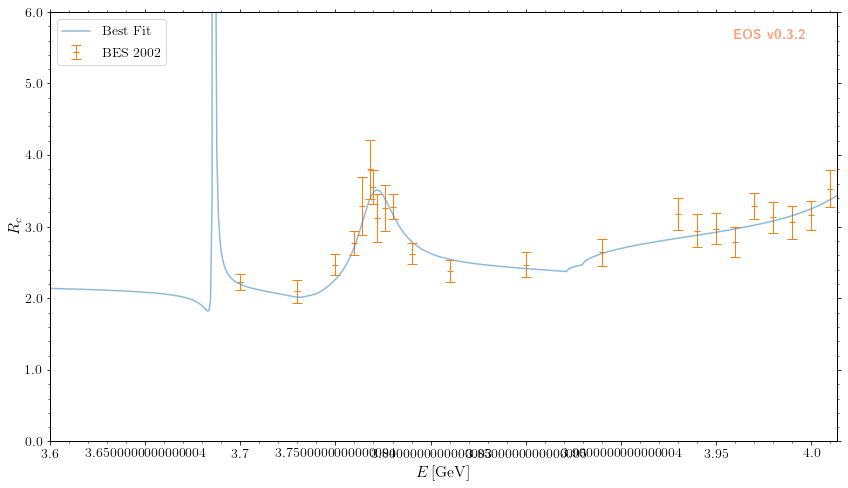

In [12]:
plotRc_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.6, 4.0137] },
        'y': { 'label': r'$R_c$',          'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::R_c(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.6, 4.0137],
            'samples': 500
        },
        {
            'label': r'BES 2002',
            'type': 'constraint',
            'constraints': 'ee->ccbar::R_c@BESII2002',
            'observable': 'ee->ccbar::R_c(E)',
            'variable': 'E',
            'rescale-by-width': False
        },

    ]
}
eos.plot.Plotter(plotRc_args).plot()

## Fit up to 4.8 GeV in the isospin limit

In [4]:
analysis_to48_args = {
    'global_options': {},
    'manual_constraints': {
        'psi2S::decay_width': {
            'type': 'Gaussian',
            'observable': 'ee->ccbar::psi2S_ee_width',
            'kinematics' : {},
            'options' : {},
            'mean': 2.331e-6,
            'sigma-stat': { 'hi': 0.064e-6, 'lo': 0.064e-6 },
            'sigma-sys': { 'hi': 0.0, 'lo': 0.0 },
            'dof': 1
        }
    },
    'priors': [
        { 'parameter': "ee->ccbar::g0(psi(2S),ee)",             'min': 0.002, 'max': 0.004,'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),ee)",           'min': -0.01, 'max': 0.01, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),ee)",           'min': -0.01, 'max': 0.01, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4160),ee)",           'min': -0.01, 'max': 0.01, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4415),ee)",           'min': -0.1,  'max': 0.1,  'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(2S),eff)",            'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),eff)",          'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),eff)",          'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4160),eff)",          'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4415),eff)",          'min': -1.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(2S),D^0Dbar^0)",      'min': -2.5, 'max':  0.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),D^0Dbar^0)",    'min':  0.0, 'max':  5.0, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(4040),D^0Dbar^0)",    'min': -5.0, 'max':  5.0, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(4160),D^0Dbar^0)",    'min': -5.0, 'max':  5.0, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(4415),D^0Dbar^0)",    'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::Rconstant",                  'min':  1.5, 'max':  2.2, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(2S),D^0Dbar^*0)",     'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),D^0Dbar^*0)",   'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),D^0Dbar^*0)",   'min': -1.0, 'max':  0.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4160),D^0Dbar^*0)",   'min': -1.0, 'max':  0.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4415),D^0Dbar^*0)",   'min': -1.0, 'max':  0.0, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(2S),D_s^+D_s^-)",     'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(3770),D_s^+D_s^-)",   'min': -5.0, 'max':  5.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4040),D_s^+D_s^-)",   'min':  0.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4160),D_s^+D_s^-)",   'min':  0.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::g0(psi(4415),D_s^+D_s^-)",   'min':  0.0, 'max':  1.0, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(2S),D^*0Dbar^*0)",    'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(3770),D^*0Dbar^*0)",  'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4040),D^*0Dbar^*0)",  'min': -1.0, 'max':  0.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4160),D^*0Dbar^*0)",  'min': -1.0, 'max':  0.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4415),D^*0Dbar^*0)",  'min': -1.0, 'max':  0.0, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(2S),D_s^+D_s^*-)",    'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(3770),D_s^+D_s^*-)",  'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4040),D_s^+D_s^*-)",  'min':  0.0, 'max':  1.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4160),D_s^+D_s^*-)",  'min':  0.0, 'max':  1.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4415),D_s^+D_s^*-)",  'min':  0.0, 'max':  1.0, 'type': 'uniform' },
##        { 'parameter': "ee->ccbar::g0(psi(2S),D_s^*+D_s^*-)",   'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(3770),D_s^*+D_s^*-)", 'min': -5.0, 'max':  5.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4040),D_s^*+D_s^*-)", 'min':  0.0, 'max':  1.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4160),D_s^*+D_s^*-)", 'min':  0.0, 'max':  1.0, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::g0(psi(4415),D_s^*+D_s^*-)", 'min':  0.0, 'max':  1.0, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,eff)",                  'min': -0.1, 'max':  0.1, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,D^0Dbar^0)",            'min': -0.1, 'max':  0.1, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,D^0Dbar^*0)",           'min': -0.1, 'max':  0.1, 'type': 'uniform' },
        { 'parameter': "ee->ccbar::c(ee,D_s^+D_s^-)",           'min': -0.1, 'max':  0.1, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::c(ee,D^*0Dbar^*0)",          'min': -0.1, 'max':  0.1, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::c(ee,D_s^+D_s^*-)",          'min': -0.1, 'max':  0.1, 'type': 'uniform' },
#        { 'parameter': "ee->ccbar::c(ee,D_s^*+D_s^*-)",         'min': -0.1, 'max':  0.1, 'type': 'uniform' },
    ],
    'likelihood': [
        'ee->ccbar::sigma_eetoD0Dbar0@Belle2008',
        'ee->ccbar::sigma_eetoDpDm@Belle2008',
        'ee->ccbar::sigma_eetoD0Dbar0@BaBar2007',
        'ee->ccbar::sigma_eetoDpDm@BaBar2007',
        'ee->ccbar::sigma_eetoD0Dbarst0@CLEO2009',
        'ee->ccbar::sigma_eetoDpDstm@CLEO2009',
        'ee->ccbar::sigma_eetoDspDsm@CLEO2009',
#        'ee->ccbar::sigma_eetoDst0Dbarst0@CLEO2009',
#        'ee->ccbar::sigma_eetoDstpDstm@CLEO2009',
        'ee->ccbar::R_c@BESII2002;begin=0,end=56',
    ]
}
analysis_to48 = eos.Analysis(**analysis_to48_args)

In [5]:
%%time
bfp_to48 = analysis_to48.optimize(
    start_point = [ 2.88377750e-03,  3.95990720e-04, -1.24776582e-03,  1.65586306e-05,  0,
                    8.99710453e-03,  1.87127261e-01, -3.74030208e-01,  2.42129552e-02,  0,
                   -2.13495389e+00,  3.27931909e+00,
                    1.69367660e+00,
                   -6.73126202e-01, -7.72233900e-01, -1.47436145e-03, -6.27612100e-03,
                    4.59335448e-01, -7.72233900e-01,  9.95400754e-01,  2.16550367e-06,
                   -7.73561329e-04, -8.77483611e-05,
                   -2.23653873e-04, -2.77686347e-04
                  ]
    )
display(bfp_to48.point)
display(analysis_to48.goodness_of_fit())

KeyboardInterrupt: 

## Plot

In [6]:
keys = np.array([#"mass::psi(3770)",
                 "ee->ccbar::g0(psi(2S),ee)",
                 "ee->ccbar::g0(psi(3770),ee)",
                 "ee->ccbar::g0(psi(4040),ee)",
                 "ee->ccbar::g0(psi(4160),ee)",
#                 "ee->ccbar::g0(psi(4415),ee)",
                 "ee->ccbar::g0(psi(2S),eff)",
                 "ee->ccbar::g0(psi(3770),eff)",
                 "ee->ccbar::g0(psi(4040),eff)",
                 "ee->ccbar::g0(psi(4160),eff)",
#                 "ee->ccbar::g0(psi(4415),eff)",
                 "ee->ccbar::g0(psi(2S),D^0Dbar^0)",
                 "ee->ccbar::g0(psi(3770),D^0Dbar^0)",
##                 "ee->ccbar::g0(psi(4040),D^0Dbar^0)",
##                 "ee->ccbar::g0(psi(4160),D^0Dbar^0)",
##                 "ee->ccbar::g0(psi(4415),D^0Dbar^0)",
                 "ee->ccbar::Rconstant",
##                 "ee->ccbar::g0(psi(2S),D^0Dbar^*0)",
                 "ee->ccbar::g0(psi(3770),D^0Dbar^*0)",
                 "ee->ccbar::g0(psi(4040),D^0Dbar^*0)",
                 "ee->ccbar::g0(psi(4160),D^0Dbar^*0)",
#                 "ee->ccbar::g0(psi(4415),D^0Dbar^*0)",
##                 "ee->ccbar::g0(psi(2S),D_s^+D_s^-)",
                 "ee->ccbar::g0(psi(3770),D_s^+D_s^-)",
                 "ee->ccbar::g0(psi(4040),D_s^+D_s^-)",
                 "ee->ccbar::g0(psi(4160),D_s^+D_s^-)",
#                 "ee->ccbar::g0(psi(4415),D_s^+D_s^-)",
##                 "ee->ccbar::g0(psi(2S),D^*0Dbar^*0)",
#                 "ee->ccbar::g0(psi(3770),D^*0Dbar^*0)",
#                 "ee->ccbar::g0(psi(4040),D^*0Dbar^*0)",
#                 "ee->ccbar::g0(psi(4160),D^*0Dbar^*0)",
#                 "ee->ccbar::g0(psi(4415),D^*0Dbar^*0)",
##                 "ee->ccbar::g0(psi(2S),D_s^+D_s^*-)",
#                 "ee->ccbar::g0(psi(3770),D_s^+D_s^*-)",
#                 "ee->ccbar::g0(psi(4040),D_s^+D_s^*-)",
#                 "ee->ccbar::g0(psi(4160),D_s^+D_s^*-)",
#                 "ee->ccbar::g0(psi(4415),D_s^+D_s^*-)",
##                 "ee->ccbar::g0(psi(2S),D_s^*+D_s^*-)",
#                 "ee->ccbar::g0(psi(3770),D_s^*+D_s^*-)",
#                 "ee->ccbar::g0(psi(4040),D_s^*+D_s^*-)",
#                 "ee->ccbar::g0(psi(4160),D_s^*+D_s^*-)",
#                 "ee->ccbar::g0(psi(4415),D_s^*+D_s^*-)",
                 "ee->ccbar::c(ee,eff)",
                 "ee->ccbar::c(ee,D^0Dbar^0)",
                 "ee->ccbar::c(ee,D^0Dbar^*0)",
                 "ee->ccbar::c(ee,D_s^+D_s^-)",
#                 "ee->ccbar::c(ee,D^*0Dbar^*0)",
#                 "ee->ccbar::c(ee,D_s^*+D_s^*-)",
#                 "ee->ccbar::c(ee,D_s^*+D_s^*-)"
                 ])
bfp_dict = dict(zip(keys, bfp_to48.point))


plotD0Dbar0_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.8] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^0 \bar{D}^0)$',   'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoD0Dbar0(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.8],
            'samples': 500
        },
        {
            'label': r'Belle 2008',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbar0@Belle2008',
            'observable': 'ee->ccbar::sigma_eetoD0Dbar0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
        {
            'label': r'BaBar 2007',
            'type': 'constraint',
            'color': 'C1',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbar0@BaBar2007',
            'observable': 'ee->ccbar::sigma_eetoD0Dbar0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotD0Dbar0_args).plot()

plotD0Dbarst0_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.8] },
        'y': { 'label': r'$\sigma(e^+e^-\to D^0 \bar{D}^{*0})$',   'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoD0Dbarst0(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.8],
            'samples': 500
        },
        {
            'label': r'CLEO 2009',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoD0Dbarst0@CLEO2009',
            'observable': 'ee->ccbar::sigma_eetoD0Dbarst0(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotD0Dbarst0_args).plot()

plotDspDsm_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.7, 4.8] },
        'y': { 'label': r'$\sigma(e^+e^-\to D_s^+ D_s^-)$',   'range': [0.,  .5]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::sigma_eetoDspDsm(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.7, 4.8],
            'samples': 500
        },
        {
            'label': r'CLEO 2009',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'ee->ccbar::sigma_eetoDspDsm@CLEO2009',
            'observable': 'ee->ccbar::sigma_eetoDspDsm(E)',
            'variable': 'E',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plotDspDsm_args).plot()

NameError: name 'bfp_to48' is not defined

In [ ]:
plotRc_args = {
    'plot': {
        'x': { 'label': r'$E$', 'unit': r'$\textnormal{GeV}$',  'range': [3.6, 4.8] },
        'y': { 'label': r'$R_c$',          'range': [0.,  6.]  },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'Best Fit',
            'type': 'observable',
            'observable': "ee->ccbar::R_c(E)",
            'parameters': bfp_dict,
            'kinematic': 'E',
            'range': [3.6, 4.8],
            'samples': 500
        },
        {
            'label': r'BES 2002',
            'type': 'constraint',
            'constraints': 'ee->ccbar::R_c@BESII2002',
            'observable': 'ee->ccbar::R_c(E)',
            'variable': 'E',
            'rescale-by-width': False
        },

    ]
}
eos.plot.Plotter(plotRc_args).plot()